# 06. Explore and curate predictors

This notebook is step 6 of the `toronto_election_turnout` rewrite. It takes the wide, uncurated
585-CT x 119-column candidate table built by `05_prepare_ct_predictor_universe.ipynb` and turns it
into the final, curated model-input table `07_fit_latent_pls_model.ipynb` (the PLS model) will read.

**This round's job is different from a prior round's.** Previously this notebook ran an open-ended
screening exercise over a wide candidate pool -- test-and-decide items, keep/drop calls on redundant
pairs, and so on. This round the predictor pool is a **fixed, explicitly pre-approved list**: 70
variables across 14 families, decided upstream and handed to this notebook as ground truth. The job
here is to **confirm** the list is clean (every name exists, missingness is light, no accidental
near-duplicates hide inside it) and **assemble** the final model-input table -- not to make judgment
calls about what belongs on the list.

**What this notebook does, in order:**

1. Loads `ct_candidate_predictors.csv`/`.geojson` and verifies every one of the 70 pre-approved
   predictor names actually exists as a column in the candidate table.
2. Explores missingness across the candidate table, and specifically within the 70-variable set.
3. Documents, with a one-line reason each, every candidate column that exists upstream but is *not*
   part of this round's approved 70 -- including the two deliberate concept-replacements described
   below.
4. Runs a pairwise-redundancy scan across the fixed 70 as a diagnostic (not a pruning tool this
   round -- the list is bounded and approved, so a high correlation is reported and explained, never
   used to silently drop a variable).
5. Median-imputes the 70 predictors plus the outcome/vote-count columns, each with a companion
   `_median_imputed` boolean flag, in one clean pass.
6. Writes `ct_model_input.csv`/`.geojson` and `predictor_metadata.csv` -- a complete, standalone record
   of every candidate column, whether it was selected into the curated 70 or excluded, and why.

**What changed upstream, reflected throughout this notebook:**

- **Electoral competitiveness (`block4_*`: margins, effective-candidate counts, fragmentation) is fully
  retired.** It does not exist anywhere in the candidate table, is not referenced here, and is not
  carried into `ct_model_input.csv`. (It remains archived elsewhere per project direction.)
- **KSI collisions, development applications, and 311 service requests are fully retired** -- these
  opportunistic "completeness" variables from a prior round no longer exist upstream.
- **The binary 1200m facility-access flags (library/community-centre/park/shelter) are fully retired**,
  replaced by nine continuous StatCan proximity indices (jobs, transit, grocery, health care,
  childcare, elementary school, secondary school, library, parks). The old finding that
  `block5_park_access_1200m` was a constant column is now moot -- that column doesn't exist.
- **Two deliberate concept-replacements** are part of this round's approved list:
  - `block2_core_housing_need_share` (combined owner **and** tenant core housing need) replaces the
    previous round's `block2_core_housing_need_tenant_share` (tenant-only).
  - `block3_non_official_language_at_home_share` (language spoken **at home**) replaces the previous
    round's `block3_non_official_mother_tongue_share` (**mother tongue**, i.e. first language learned)
    -- a genuinely different Census concept, not just a rename.
- **The ethnic-origin diversity index is fully removed.** A prior round added `ethnic_diversity_index`
  (a Simpson's-index summary of `census.parquet` ethnic-origin shares) as a test-and-decide promotion.
  It is not part of this round's explicitly bounded 70-variable list, so it is not computed, tested, or
  carried into any output here.

**This notebook does not re-derive the curation philosophy.** The 70-variable, 14-family list below was
decided upstream and is treated as ground truth; the job here is to verify it, stress-test it for
hidden collinearity, and document it -- not to add or remove variables by judgment call.

In [1]:
import json
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 50)

In [2]:
REPO_ROOT = Path.cwd().resolve().parents[1]
DATA_ROOT = REPO_ROOT / "data" / "toronto_election_turnout"  # relocated output root (was analysis/toronto_election_turnout/data)
FEATURES_DIR = DATA_ROOT / "features"

CANDIDATE_CSV = FEATURES_DIR / "ct_candidate_predictors.csv"
CANDIDATE_GEOJSON = FEATURES_DIR / "ct_candidate_predictors.geojson"

OUTPUT_CSV = FEATURES_DIR / "ct_model_input.csv"
OUTPUT_GEOJSON = FEATURES_DIR / "ct_model_input.geojson"
OUTPUT_METADATA = FEATURES_DIR / "predictor_metadata.csv"

TARGET = "mean_turnout"

# --- The fixed, pre-approved curated predictor list --------------------------
# 70 variables across 14 families, decided upstream. This notebook's job is to
# verify every name exists, check missingness/collinearity, and assemble the
# final table -- not to add or drop variables by judgment call.
CURATED_FAMILIES = {
    "age_life_stage": [
        "block1_age_18_29_share", "block1_age_30_64_share", "block1_age_65_plus_share",
        "block5_school_age_5_17_share",
    ],
    "household_family": [
        "block1_average_household_size", "block1_one_person_household_share",
        "block1_one_parent_family_share", "block1_multigenerational_household_share",
        "block1_married_or_common_law_share", "block1_never_married_share",
    ],
    "education": [
        "block1_bachelors_or_higher_25_64_share", "block1_college_or_trades_25_64_share",
        "block1_high_school_or_less_share",
    ],
    "income_class": [
        "block1_median_household_income", "block1_low_income_lim_at_share",
    ],
    "labour_market": [
        "block1_employment_rate_share", "block1_unemployment_rate_share",
        "block1_not_in_labour_force_share", "block1_temporary_worker_share",
        "block1_self_employment_share",
    ],
    "occupation": [
        "block1_occ_management_share", "block1_occ_business_finance_admin_share",
        "block1_occ_education_law_social_gov_share", "block1_occ_natural_applied_sciences_share",
        "block1_occ_sales_service_share", "block1_occ_trades_transport_share",
        "block1_occ_manufacturing_share", "block1_occ_arts_recreation_sport_share",
    ],
    "housing_tenure_stability": [
        "block2_renter_share", "block2_same_address_5yr_share", "block2_recent_mover_share",
    ],
    "housing_form": [
        "block2_apartment_share", "block2_condo_share", "block2_detached_share",
        "block2_high_rise_apartment_share", "block2_dwelling_vintage_pre1960_share",
        "block2_dwelling_vintage_1961_1990_share",
    ],
    "housing_affordability_need": [
        "block2_shelter_cost_burden_30plus_share", "block2_core_housing_need_share",
        "block5_social_housing_share", "block2_dwelling_major_repairs_needed_share",
    ],
    "immigration_citizenship": [
        "block3_immigrant_share", "block3_recent_immigrant_share", "block3_non_citizen_share",
        "block3_first_generation_share", "block3_second_generation_share",
    ],
    "culture_language": [
        "block3_visible_minority_share", "block3_no_religion_share",
        "block3_non_official_language_at_home_share", "block3_neither_english_nor_french_share",
    ],
    "transportation": [
        "block5_tts_no_car_household_share", "block5_tts_vehicles_per_household",
        "block5_tts_transit_trip_share", "block5_tts_auto_trip_share",
        "block5_tts_walk_or_bike_trip_share", "block5_tts_avg_trip_distance_km",
        "block5_tts_trips_per_person", "block5_census_long_commute_60min_share",
        "block5_census_work_from_home_share",
    ],
    "urban_form": [
        "block2_population_density_per_km2", "block5_distance_city_hall_km",
    ],
    "accessibility": [
        "block5_jobs_proximity_index", "block5_transit_proximity_index",
        "block5_grocery_proximity_index", "block5_health_care_proximity_index",
        "block5_childcare_proximity_index", "block5_elementary_school_proximity_index",
        "block5_secondary_school_proximity_index", "block5_library_proximity_index",
        "block5_parks_proximity_index",
    ],
}

# Pure identifiers / geometry keys -- never predictors, never imputed.
IDENTIFIER_COLUMNS = ["ct_id", "ctuid", "dguid", "geo_name", "census_year"]

# Outcome and vote-count columns -- not predictors, but median-imputed alongside the
# curated 70 (same imputation pass) and always carried through to ct_model_input.csv.
# TARGET ("mean_turnout") is one of these.
OUTCOME_COLUMNS = [
    "citizen_canadian_18over",
    "municipal_votes_cast", "municipal_turnout", "municipal_estimated_electors",
    "municipal_turnout_electors_diagnostic",
    "provincial_votes_cast", "provincial_turnout", "provincial_estimated_electors",
    "provincial_turnout_electors_diagnostic",
    "federal_votes_cast", "federal_turnout", "federal_estimated_electors",
    "federal_turnout_electors_diagnostic",
    "mean_turnout",
]

# Every other candidate-table column that is neither an identifier, an outcome column,
# nor part of the approved 70 -- kept as passthrough reference columns in
# ct_model_input.csv (un-imputed), flagged family="excluded" in predictor_metadata.csv
# with a one-line rationale each. Nothing is silently dropped from the file.
EXCLUDED_COLUMNS = [
    "population_total", "population_18plus", "citizen_canadian_18plus_count", "land_area_km2",
    "block1_median_age", "block2_owner_share", "block2_same_address_1yr_share",
    "block2_semi_detached_share", "block2_structural_type_total_dwellings",
    "block2_apartment_duplex_count", "block2_apartment_lt5_storeys_count",
    "block2_apartment_5plus_storeys_count", "block2_apartment_total_count",
    "block2_condo_status_total_dwellings", "block2_condominium_dwellings_count",
    "block2_apartments_per_km2", "block2_condos_per_km2",
    "block3_citizen_adult_share", "block3_english_french_knowledge_share",
    "block3_non_official_mother_tongue_share", "block5_census_transit_commute_share",
    "block1_couple_with_children_share", "block1_labour_force_participation_rate",
    "block1_full_time_year_round_work_share", "block2_core_housing_need_tenant_share",
    "block3_non_permanent_resident_share", "block5_tts_overlap_area_m2",
    "block5_transit_commute_share_preferred", "block5_no_car_household_share",
    "block5_social_housing_note",
]

# General pairwise-redundancy scan threshold. This round's list is fixed and
# pre-approved, so a flagged pair is documented, never used to drop a variable.
GENERAL_REDUNDANCY_THRESHOLD = 0.9

print(f"CURATED_FAMILIES: {len(CURATED_FAMILIES)} families, "
      f"{sum(len(v) for v in CURATED_FAMILIES.values())} variables")
print(f"OUTCOME_COLUMNS: {len(OUTCOME_COLUMNS)}")
print(f"IDENTIFIER_COLUMNS: {len(IDENTIFIER_COLUMNS)}")
print(f"EXCLUDED_COLUMNS: {len(EXCLUDED_COLUMNS)}")

CURATED_FAMILIES: 14 families, 70 variables
OUTCOME_COLUMNS: 14
IDENTIFIER_COLUMNS: 5
EXCLUDED_COLUMNS: 30


## 1. Load the candidate table and verify the curated list against it

`ct_candidate_predictors.csv` is notebook 05's output: 585 CTs, 119 columns, read-only, no curation
or imputation applied. We load both the flat CSV (for all analysis) and the geometry-carrying
GeoJSON (geometry is needed only when writing the final output).

In [3]:
candidates = pd.read_csv(CANDIDATE_CSV)
candidates["ct_id"] = candidates["ct_id"].astype(float)
candidates["ctuid_f"] = candidates["ctuid"].astype(float)

candidate_gdf = gpd.read_file(CANDIDATE_GEOJSON)[["ct_id", "geometry"]]
candidate_gdf["ct_id"] = candidate_gdf["ct_id"].astype(float)

print(f"Candidate table: {candidates.shape[0]} rows x {candidates.shape[1]} columns")
print(f"Candidate geometry: {candidate_gdf.shape[0]} rows")
assert candidates.shape[0] == 585, "Expected 585 CTs in the candidate table."
assert set(candidates["ct_id"]) == set(candidate_gdf["ct_id"]), "ct_id mismatch between CSV and GeoJSON." 

Candidate table: 585 rows x 120 columns
Candidate geometry: 585 rows


### Verify every one of the 70 pre-approved variable names exists

Every column name in `CURATED_FAMILIES` is checked against the actual candidate-table column list
below; a schema mismatch fails loudly rather than silently dropping a variable. This is a pure
verification step -- nothing here is a judgment call, since the list itself was decided upstream.

In [4]:
flat_curated = [v for cols in CURATED_FAMILIES.values() for v in cols]
print(f"CURATED_FAMILIES enumerates {len(flat_curated)} variables ({len(set(flat_curated))} unique) "
      f"across {len(CURATED_FAMILIES)} families.")
print("Per-family counts:")
for fam, cols in CURATED_FAMILIES.items():
    print(f"  {fam:30s} {len(cols)}")

missing_from_candidates = [c for c in flat_curated if c not in candidates.columns]
print(f"\nMissing from ct_candidate_predictors.csv: {missing_from_candidates}")
assert not missing_from_candidates, (
    "One or more CURATED_FAMILIES columns do not exist in the candidate table -- stopping rather "
    "than silently proceeding."
)
assert len(flat_curated) == len(set(flat_curated)), "Duplicate variable name across families."
assert len(flat_curated) == 70, f"Expected exactly 70 approved predictors, found {len(flat_curated)}."

# Every other accounted-for column list should also exist, and the four groups
# (curated + outcome + identifier + excluded) should partition the full candidate table exactly.
for label, cols in [("OUTCOME_COLUMNS", OUTCOME_COLUMNS), ("IDENTIFIER_COLUMNS", IDENTIFIER_COLUMNS),
                    ("EXCLUDED_COLUMNS", EXCLUDED_COLUMNS)]:
    missing = [c for c in cols if c not in candidates.columns]
    assert not missing, f"{label} references column(s) not in the candidate table: {missing}"

all_accounted = set(flat_curated) | set(OUTCOME_COLUMNS) | set(IDENTIFIER_COLUMNS) | set(EXCLUDED_COLUMNS)
unaccounted = set(candidates.columns) - all_accounted - {"ctuid_f"}
print(f"\nCandidate table columns not accounted for by any of the four groups: {sorted(unaccounted)}")
assert not unaccounted, "Found a candidate-table column not classified into curated/outcome/identifier/excluded."
print("\nAll 70 approved variables verified present and unique, and every candidate-table column is "
      "accounted for (curated, outcome, identifier, or excluded).")

CURATED_FAMILIES enumerates 70 variables (70 unique) across 14 families.
Per-family counts:
  age_life_stage                 4
  household_family               6
  education                      3
  income_class                   2
  labour_market                  5
  occupation                     8
  housing_tenure_stability       3
  housing_form                   6
  housing_affordability_need     4
  immigration_citizenship        5
  culture_language               4
  transportation                 9
  urban_form                     2
  accessibility                  9

Missing from ct_candidate_predictors.csv: []

Candidate table columns not accounted for by any of the four groups: []

All 70 approved variables verified present and unique, and every candidate-table column is accounted for (curated, outcome, identifier, or excluded).


## 2. Missingness across the candidate table

A broad look first, then a focused look at just the 70 approved predictors. The candidate table is
Blocks 1-5 joined from several different source pipelines (census profile, TTS, `census.parquet`
proximity indices), so some columns have a handful of CTs with missing values; the question is
whether any approved predictor has enough missingness to be a concern before committing to median
imputation.

In [5]:
full_missing = candidates.isna().sum().sort_values(ascending=False)
full_missing = full_missing[full_missing > 0]
print(f"{len(full_missing)} of {candidates.shape[1]} candidate columns have at least one missing value "
      f"(out of 585 rows).")
if len(full_missing):
    print(f"Worst column: {full_missing.index[0]} ({full_missing.iloc[0]} missing, "
          f"{full_missing.iloc[0] / 585:.1%}).")
full_missing.head(10)

79 of 120 candidate columns have at least one missing value (out of 585 rows).
Worst column: block5_secondary_school_proximity_index (100 missing, 17.1%).


block5_secondary_school_proximity_index     100
block5_library_proximity_index               81
block5_grocery_proximity_index               16
block5_elementary_school_proximity_index      4
block5_census_transit_commute_share           3
block5_parks_proximity_index                  3
block5_transit_proximity_index                3
block5_census_long_commute_60min_share        3
block2_condo_share                            2
block2_apartment_share                        2
dtype: int64

In [6]:
curated_missing = candidates[flat_curated].isna().sum().sort_values(ascending=False)
curated_missing = curated_missing[curated_missing > 0]
print("Missingness within the 70 approved predictors only:")
curated_missing

Missingness within the 70 approved predictors only:


block5_secondary_school_proximity_index       100
block5_library_proximity_index                 81
block5_grocery_proximity_index                 16
block5_elementary_school_proximity_index        4
block5_census_long_commute_60min_share          3
block5_parks_proximity_index                    3
block5_transit_proximity_index                  3
block5_census_work_from_home_share              2
block3_no_religion_share                        2
block2_dwelling_vintage_1961_1990_share         2
block1_one_person_household_share               2
block1_average_household_size                   2
block2_shelter_cost_burden_30plus_share         2
block1_one_parent_family_share                  2
block1_temporary_worker_share                   2
block1_multigenerational_household_share        2
block1_college_or_trades_25_64_share            2
block1_bachelors_or_higher_25_64_share          2
block1_high_school_or_less_share                2
block1_median_household_income                  2


**Takeaway:** missingness across the full 120-column candidate table is 79 columns with at least
one missing value, out of 585 CTs. Within the 70 approved predictors specifically, 40 columns have at
least one missing value; the overwhelming majority of those are 1-2 CTs (0.2-0.3%, StatCan
rounding/suppression or a handful of CTs sitting just outside a source dataset's coverage). Three
`census.parquet` proximity indices stand out with meaningfully higher missingness:
`block5_secondary_school_proximity_index` (100 of 585 CTs, 17.1%), `block5_library_proximity_index`
(81 of 585, 13.8%), and `block5_grocery_proximity_index` (16 of 585, 2.7%) -- these three CTs sets
likely sit outside that index's underlying coverage area. Even the worst case here is well short of a
level that would justify dropping an approved predictor (the list is fixed this round regardless), so
a per-column median fill is used for all of them -- a transparent, low-impact way to keep every CT in
the model-input table while flagging exactly which rows were touched. See Section 5 for the full
imputation pass.

## 3. Candidate columns not part of this round's approved 70

This round's predictor pool is a **fixed, pre-approved list**, not an open-ended screen -- so nothing
below is a new judgment call made in this notebook. Several categories that existed in a prior round's
candidate pool are simply **absent upstream now** and need no exclusion bookkeeping here at all:

- All `block4_*` electoral-competitiveness columns (margins, effective-candidate counts, fragmentation)
  -- fully retired; archived elsewhere per project direction.
- KSI collisions, development applications, and 311 service requests -- fully retired.
- The binary 1200m facility-access flags (library/community-centre/park/shelter) -- fully retired,
  replaced by the nine continuous proximity indices in the `accessibility` family.
- The ethnic-origin diversity index (`ethnic_diversity_index`) -- a prior round's test-and-decide
  addition, not part of this round's bounded list; not computed or referenced anywhere in this
  notebook.

What **does** still exist in the candidate table but is **not** selected into the approved 70 is listed
in `EXCLUDED_COLUMNS` above and given a one-line rationale each in `predictor_metadata.csv` (Section 6).
Two of these are deliberate, named concept-replacements rather than ordinary non-selections:

- **`block2_core_housing_need_share`** (combined owner **and** tenant core housing need, in the
  approved list) replaces **`block2_core_housing_need_tenant_share`** (tenant-only, excluded) in the
  `housing_affordability_need` family.
- **`block3_non_official_language_at_home_share`** (language spoken **at home**, in the approved list)
  replaces **`block3_non_official_mother_tongue_share`** (**mother tongue** -- first language learned,
  excluded) in the `culture_language` family. These are genuinely different Census concepts (current
  linguistic environment vs. first language learned), not a rename.

The rest of `EXCLUDED_COLUMNS` are raw counts that feed other derived shares (e.g. dwelling-structure
counts, population/citizen base counts), or share-type candidates that were simply not chosen into the
approved family list (e.g. `block1_median_age`, `block2_owner_share`, `block3_citizen_adult_share`).
All of them are kept as passthrough reference columns in `ct_model_input.csv` -- nothing is silently
dropped from the file.

In [7]:
print(f"{len(EXCLUDED_COLUMNS)} candidate-table columns exist upstream but are not part of the "
      f"approved 70:")
for c in EXCLUDED_COLUMNS:
    print(f"  {c}")

overlap = set(EXCLUDED_COLUMNS) & set(flat_curated)
assert not overlap, f"EXCLUDED_COLUMNS overlaps with the approved 70: {overlap}"
print("\nConfirmed: EXCLUDED_COLUMNS and the approved 70 are disjoint.")

30 candidate-table columns exist upstream but are not part of the approved 70:
  population_total
  population_18plus
  citizen_canadian_18plus_count
  land_area_km2
  block1_median_age
  block2_owner_share
  block2_same_address_1yr_share
  block2_semi_detached_share
  block2_structural_type_total_dwellings
  block2_apartment_duplex_count
  block2_apartment_lt5_storeys_count
  block2_apartment_5plus_storeys_count
  block2_apartment_total_count
  block2_condo_status_total_dwellings
  block2_condominium_dwellings_count
  block2_apartments_per_km2
  block2_condos_per_km2
  block3_citizen_adult_share
  block3_english_french_knowledge_share
  block3_non_official_mother_tongue_share
  block5_census_transit_commute_share
  block1_couple_with_children_share
  block1_labour_force_participation_rate
  block1_full_time_year_round_work_share
  block2_core_housing_need_tenant_share
  block3_non_permanent_resident_share
  block5_tts_overlap_area_m2
  block5_transit_commute_share_preferred
  block5_n

## 4. General redundancy / correlation scan

This round's 70-variable list is fixed and explicitly approved -- so this scan is a **diagnostic**, not
a pruning tool. PLS (the model notebook 07 fits) handles collinearity natively -- it's specifically
built to extract components from correlated predictor blocks -- so a high pairwise correlation here is
reported and explained for interpretation purposes, never used to silently drop a variable from the
approved list.

One pair is specifically expected to show up: `block5_tts_no_car_household_share` vs.
`block5_tts_vehicles_per_household`, which correlated at `r ~ -0.91` in a prior round's screening (both
are derived from the same TTS household vehicle-count distribution). Per this round's brief, both stay
in the approved list regardless -- the finding below just confirms and documents it for notebook 07's
interpretation of the fitted PLS components.

In [8]:
corr_matrix = candidates[flat_curated].corr()

high_corr_pairs = []
cols = corr_matrix.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        r = corr_matrix.iloc[i, j]
        if pd.notna(r) and abs(r) > GENERAL_REDUNDANCY_THRESHOLD:
            high_corr_pairs.append({"variable_a": cols[i], "variable_b": cols[j], "r": r})

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values(
    "r", key=lambda s: s.abs(), ascending=False
).reset_index(drop=True) if high_corr_pairs else pd.DataFrame(columns=["variable_a", "variable_b", "r"])
print(f"{len(high_corr_df)} pairs with |r| > {GENERAL_REDUNDANCY_THRESHOLD} among the 70 approved predictors:")
high_corr_df

8 pairs with |r| > 0.9 among the 70 approved predictors:


,variable_a,variable_b,r
0,block3_immigrant_share,block3_first_generation_share,0.972799
1,block1_employment_rate_share,block1_not_in_labour_force_share,-0.972297
2,block1_bachelors_or_higher_25_64_share,block1_high_school_or_less_share,-0.961440
3,block1_average_household_size,block1_one_person_household_share,-0.950821
4,block2_same_address_5yr_share,block2_recent_mover_share,-0.927706
5,block5_tts_auto_trip_share,block5_tts_walk_or_bike_trip_share,-0.917414
6,block1_bachelors_or_higher_25_64_share,block5_census_work_from_home_share,0.913968
7,block5_tts_no_car_household_share,block5_tts_vehicles_per_household,-0.909838


In [9]:
r_no_car_vs_vehicles = candidates[[
    "block5_tts_no_car_household_share", "block5_tts_vehicles_per_household",
]].corr().iloc[0, 1]
print(f"corr(block5_tts_no_car_household_share, block5_tts_vehicles_per_household) = "
      f"{r_no_car_vs_vehicles:.3f}")
print(
    "Confirmed: a known, strong negative collinearity -- both are derived from the same TTS "
    "household vehicle-count distribution (a zero-car binary share and a continuous mean of the same "
    "underlying quantity). Per this round's approved list, both are kept; this is documented as a "
    "known collinearity to watch for when interpreting the PLS components in notebook 07, not a "
    "reason to drop either variable."
)

corr(block5_tts_no_car_household_share, block5_tts_vehicles_per_household) = -0.910
Confirmed: a known, strong negative collinearity -- both are derived from the same TTS household vehicle-count distribution (a zero-car binary share and a continuous mean of the same underlying quantity). Per this round's approved list, both are kept; this is documented as a known collinearity to watch for when interpreting the PLS components in notebook 07, not a reason to drop either variable.


**Decision on every flagged pair: keep both, document the correlation.** This round's list is
fixed and pre-approved, so the scan exists purely to surface and explain collinearity for notebook
07's PLS interpretation -- not to make exclusion calls. 8 pairs cleared the `|r| > 0.9` bar:

| Pair | r | Note |
|---|---|---|
| `block3_immigrant_share` / `block3_first_generation_share` | 0.97 | Structural: first-generation Canadians are defined as born outside Canada, nearly the same population as "immigrant." Kept -- both retained per the approved list; treat as near-duplicate when interpreting PLS loadings. |
| `block1_employment_rate_share` / `block1_not_in_labour_force_share` | -0.97 | Close to mechanically linked (higher employment leaves less room for labour-force withdrawal specifically, though the two are not an exact complement). Kept. |
| `block1_bachelors_or_higher_25_64_share` / `block1_high_school_or_less_share` | -0.96 | Two ends of the same education-attainment distribution. Kept -- expected, substantial overlap in what they capture. |
| `block1_average_household_size` / `block1_one_person_household_share` | -0.95 | Mechanically linked (more one-person households pulls the mean size down) but a continuous mean vs. a specific household-type share. Kept. |
| `block2_same_address_5yr_share` / `block2_recent_mover_share` | -0.93 | Two mobility-horizon shares (5-year stability vs. 1-year mobility) moving inversely, as expected. Kept. |
| `block5_tts_auto_trip_share` / `block5_tts_walk_or_bike_trip_share` | -0.92 | Two trip-mode shares trading off within a shared mode-share total -- a substantively meaningful axis (car-dependence vs. active transportation), not a duplicate measurement. Kept. |
| `block1_bachelors_or_higher_25_64_share` / `block5_census_work_from_home_share` | 0.91 | Education attainment vs. work-mode behaviour -- a substantive finding (professional work correlates with remote work), not the same measurement. Kept. |
| `block5_tts_no_car_household_share` / `block5_tts_vehicles_per_household` | -0.91 | The pair specifically flagged in the brief -- both derived from the same TTS household vehicle-count distribution. Kept per the brief's explicit instruction; documented as a known collinearity for notebook 07's PLS interpretation. |

None of these are dropped -- this round's approved list is fixed, and PLS handles correlated predictor
blocks natively. Every pair above is recorded in `predictor_metadata.csv`'s rationale text (directly,
for the no-car/vehicles pair) or here, so notebook 07 can account for it when interpreting component
loadings.

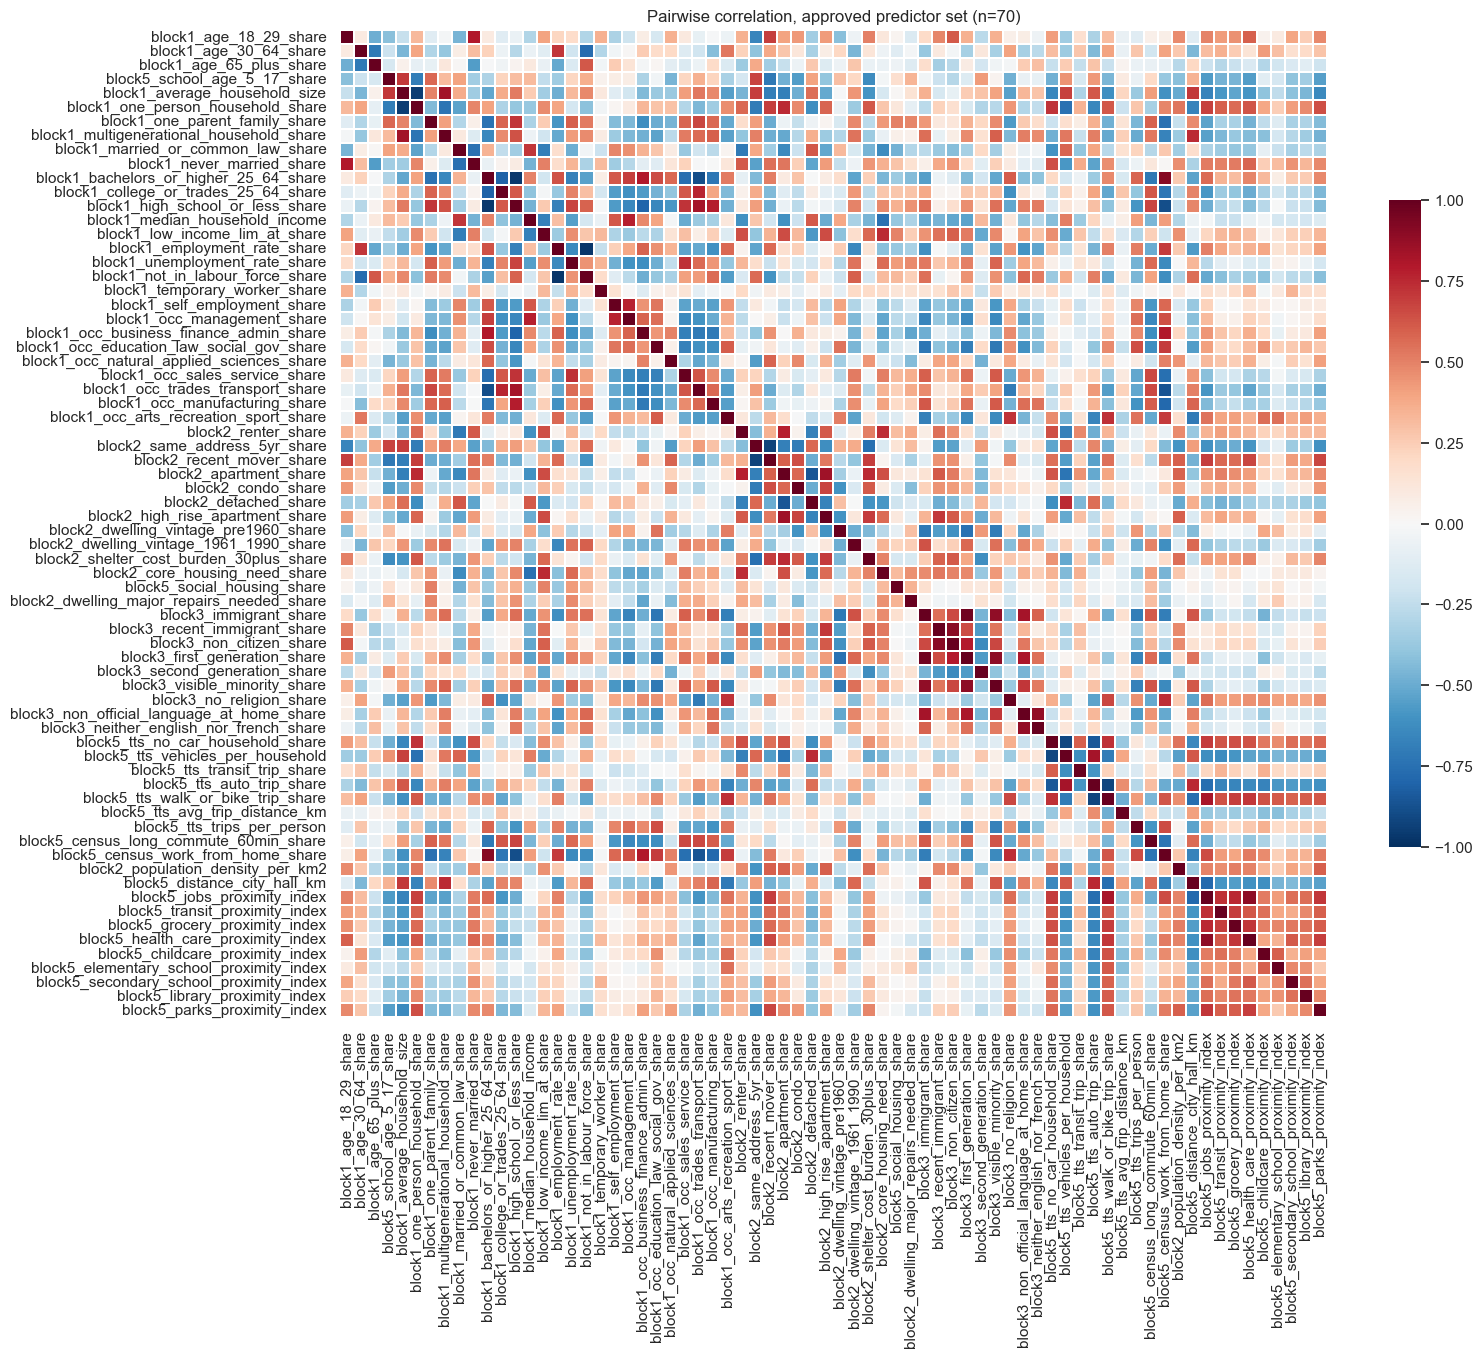

In [10]:
plt.figure(figsize=(16, 14))
final_corr = candidates[flat_curated].corr()
sns.heatmap(
    final_corr, cmap="RdBu_r", vmin=-1, vmax=1, center=0,
    square=True, linewidths=0.2, cbar_kws={"shrink": 0.6},
    xticklabels=True, yticklabels=True,
)
plt.title(f"Pairwise correlation, approved predictor set (n={len(flat_curated)})")
plt.tight_layout()
plt.show()

## 5. Missingness within the final model-input columns

The columns about to be median-imputed: the 70 approved predictors plus the outcome/vote-count
columns. Same light missingness pattern as Section 2 -- confirmed again here on the exact column list
that will actually be imputed.

In [11]:
MODEL_COLUMNS = sorted(set(flat_curated) | set(OUTCOME_COLUMNS))
print(f"{len(MODEL_COLUMNS)} columns entering median imputation "
      f"({len(flat_curated)} approved predictors + {len(OUTCOME_COLUMNS)} outcome/vote-count columns, "
      f"no overlap).")

model_missing = candidates[MODEL_COLUMNS].isna().sum().sort_values(ascending=False)
model_missing = model_missing[model_missing > 0]
print(f"\n{len(model_missing)} of {len(MODEL_COLUMNS)} model columns have at least one missing value:")
model_missing

84 columns entering median imputation (70 approved predictors + 14 outcome/vote-count columns, no overlap).

63 of 84 model columns have at least one missing value:


block5_secondary_school_proximity_index       100
block5_library_proximity_index                 81
block5_grocery_proximity_index                 16
block5_elementary_school_proximity_index        4
block5_transit_proximity_index                  3
                                             ... 
block3_neither_english_nor_french_share         1
block3_non_official_language_at_home_share      1
block5_health_care_proximity_index              1
block5_childcare_proximity_index                1
block5_jobs_proximity_index                     1
Length: 63, dtype: int64

## 6. Median imputation

For each column in `MODEL_COLUMNS`, missing values (only if the column has at least one observed
value) are filled with that column's own median across observed CTs, and a companion
`{col}_median_imputed` boolean column records which rows were touched. One clean pass over the full
`MODEL_COLUMNS` list.

In [12]:
def impute_rows(frame: pd.DataFrame, columns: list[str]) -> tuple[pd.DataFrame, pd.DataFrame]:
    out = frame.copy()
    report = []
    for col in columns:
        vals = pd.to_numeric(out[col], errors="coerce")
        present = vals.dropna()
        missing = int(vals.isna().sum())
        if present.empty:
            report.append({"variable": col, "missing_count": missing, "imputed_count": 0, "median": None})
            continue
        med = present.median()
        is_missing = vals.isna()
        out[col] = vals.where(~is_missing, med)
        out[f"{col}_median_imputed"] = is_missing
        report.append({"variable": col, "missing_count": missing, "imputed_count": int(is_missing.sum()), "median": med})
    return out, pd.DataFrame(report)


model_input, imputation_report = impute_rows(candidates, MODEL_COLUMNS)
print(f"Imputed table: {model_input.shape[0]} rows x {model_input.shape[1]} columns "
      f"(added {len(MODEL_COLUMNS)} *_median_imputed flag columns)")
imputation_report.sort_values("missing_count", ascending=False).head(15)

Imputed table: 585 rows x 204 columns (added 84 *_median_imputed flag columns)


/tmp/ipykernel_1468295/2281762431.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[f"{col}_median_imputed"] = is_missing
/tmp/ipykernel_1468295/2281762431.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[f"{col}_median_imputed"] = is_missing
/tmp/ipykernel_1468295/2281762431.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragme

,variable,missing_count,imputed_count,median
60,block5_secondary_school_proximity_index,100,100,0.065400
57,block5_library_proximity_index,81,81,0.089550
54,block5_grocery_proximity_index,16,16,0.069900
53,block5_elementary_school_proximity_index,4,4,0.176300
62,block5_transit_proximity_index,3,3,0.039300
58,block5_parks_proximity_index,3,3,0.076250
49,block5_census_long_commute_60min_share,3,3,0.116175
18,block1_occ_manufacturing_share,2,2,0.030675
8,block1_low_income_lim_at_share,2,2,0.115385
10,block1_median_household_income,2,2,86000.000000


**Takeaway:** the imputed-cell counts above match Section 5's missingness exactly, by
construction -- 63 of the 84 model columns needed at least one imputed cell. The worst cases are the
same three proximity indices flagged in Section 2 (`block5_secondary_school_proximity_index`, 100
CTs; `block5_library_proximity_index`, 81 CTs; `block5_grocery_proximity_index`, 16 CTs); every other
affected column needed only 1-4 CTs filled. Nothing here is a concern for the PLS model notebook 07
will fit, and the `*_median_imputed` flags let that notebook check sensitivity to the imputed rows if
needed.

## 7. Assemble and save the final outputs

`model_input` already carries every candidate column from notebook 05 untouched (the 30
`EXCLUDED_COLUMNS` passthrough columns are left exactly as they came in, un-imputed, per the brief),
plus the full set of `{col}_median_imputed` flag columns from Section 6.

Two files are written:
- `ct_model_input.csv` / `.geojson` -- this **overwrites** the previous round's files of the same name
  (the direct successor artifact, not an accidental overwrite of something unrelated).
- `predictor_metadata.csv` -- one row per candidate-table column that is either part of the approved 70
  or explicitly excluded (family, rationale, and where relevant, the superseded alternative), so this
  one file is a complete, standalone record of every candidate column's fate.

In [13]:
FEATURES_DIR.mkdir(parents=True, exist_ok=True)
model_input.to_csv(OUTPUT_CSV, index=False)
print(f"Wrote {model_input.shape[0]} rows x {model_input.shape[1]} columns to "
      f"{OUTPUT_CSV.relative_to(REPO_ROOT)}")

geometry_lookup = candidate_gdf.set_index("ct_id").geometry  # EPSG:4326, from notebook 05
model_input_gdf = gpd.GeoDataFrame(
    model_input, geometry=[geometry_lookup[cid] for cid in model_input["ct_id"]], crs=4326
)
model_input_gdf.to_file(OUTPUT_GEOJSON, driver="GeoJSON")
print(f"Wrote geometry-carrying copy to {OUTPUT_GEOJSON.relative_to(REPO_ROOT)}")

Wrote 585 rows x 204 columns to data/toronto_election_turnout/features/ct_model_input.csv


Wrote geometry-carrying copy to data/toronto_election_turnout/features/ct_model_input.geojson


In [14]:
RATIONALE = {
    # age_life_stage
    "block1_age_18_29_share": (
        "Share of population aged 18-29; young adults are consistently associated with lower "
        "turnout propensity, a core age-structure predictor."
    ),
    "block1_age_30_64_share": (
        "Share of population aged 30-64; the prime working/voting-age middle band, using this "
        "round's 18-29/30-64 age-share boundary."
    ),
    "block1_age_65_plus_share": (
        "Share of population aged 65+; older residents vote at substantially higher rates, one of "
        "the strongest expected turnout correlates."
    ),
    "block5_school_age_5_17_share": (
        "Share of population aged 5-17; a proxy for family/school-age household presence, distinct "
        "from the household-structure shares in the household_family family."
    ),
    # household_family
    "block1_average_household_size": "Mean persons per household; summarizes overall household scale.",
    "block1_one_person_household_share": (
        "Share of households with a single occupant; captures solo living arrangements distinct "
        "from the mean household size."
    ),
    "block1_one_parent_family_share": (
        "Share of census families headed by a single parent; a distinct family-structure and "
        "economic-stress dimension."
    ),
    "block1_multigenerational_household_share": (
        "Share of households spanning 3+ generations; often elevated in immigrant and some cultural "
        "communities, distinct from simple household size."
    ),
    "block1_married_or_common_law_share": (
        "Share of the population in a married or common-law union; a marital-status dimension of "
        "household stability."
    ),
    "block1_never_married_share": (
        "Share of the population who have never married; a complementary marital-status dimension "
        "(not a strict complement of married_or_common_law_share, since it excludes "
        "separated/widowed/divorced residents)."
    ),
    # education
    "block1_bachelors_or_higher_25_64_share": (
        "Share of the core working-age population (25-64) with a bachelor's degree or higher; the "
        "standard socioeconomic-status/education predictor in turnout research."
    ),
    "block1_college_or_trades_25_64_share": (
        "Share of the core working-age population with college or trades credentials; distinguishes "
        "a vocational/skilled-trades pathway from the university-credentialed share above."
    ),
    "block1_high_school_or_less_share": (
        "Share of the population whose highest credential is high school or less; the lower tail of "
        "the education-attainment distribution, completing the attainment picture."
    ),
    # income_class
    "block1_median_household_income": "Median household income; the core income-level predictor.",
    "block1_low_income_lim_at_share": (
        "Share of the population below the Low Income Measure, After Tax; the core material-"
        "hardship predictor, distinct from median income (level vs. hardship)."
    ),
    # labour_market
    "block1_employment_rate_share": (
        "Employment rate (employed share of the working-age population); the core "
        "labour-market-engagement predictor."
    ),
    "block1_unemployment_rate_share": "Unemployment rate; a standard economic-precarity indicator.",
    "block1_not_in_labour_force_share": (
        "Share of the working-age population neither employed nor unemployed-and-looking; captures "
        "labour-force withdrawal distinct from unemployment specifically."
    ),
    "block1_temporary_worker_share": (
        "Share of employees in temporary (non-permanent) jobs; an employment-precarity measure "
        "distinct from the unemployment rate."
    ),
    "block1_self_employment_share": (
        "Share of workers who are self-employed; a distinct labour-market-structure dimension "
        "(independent/gig work vs. standard employment)."
    ),
    # occupation
    "block1_occ_management_share": "Share of workers in management occupations.",
    "block1_occ_business_finance_admin_share": (
        "Share of workers in business, finance, and administration occupations."
    ),
    "block1_occ_education_law_social_gov_share": (
        "Share of workers in education, law, and social/government-services occupations -- includes "
        "public-sector-adjacent, civically-engaged professions."
    ),
    "block1_occ_natural_applied_sciences_share": (
        "Share of workers in natural and applied sciences occupations."
    ),
    "block1_occ_sales_service_share": "Share of workers in sales and service occupations.",
    "block1_occ_trades_transport_share": (
        "Share of workers in trades, transport, and equipment-operation occupations."
    ),
    "block1_occ_manufacturing_share": "Share of workers in manufacturing and utilities occupations.",
    "block1_occ_arts_recreation_sport_share": (
        "Share of workers in art, culture, recreation, and sport occupations."
    ),
    # housing_tenure_stability
    "block2_renter_share": "Share of households renting (vs. owning); the core tenure predictor.",
    "block2_same_address_5yr_share": (
        "Share of the population living at the same address 5 years ago; a residential-stability "
        "measure, the longer of the two mobility horizons."
    ),
    "block2_recent_mover_share": (
        "Share of the population who moved in the past year; a short-horizon residential-mobility "
        "measure, distinct from the 5-year stability share above."
    ),
    # housing_form
    "block2_apartment_share": (
        "Share of dwellings that are apartments (any size); the core apartment-vs-other-form "
        "predictor."
    ),
    "block2_condo_share": (
        "Share of dwellings held in condominium form; a distinct ownership/legal-structure "
        "dimension from the apartment/detached physical-form shares."
    ),
    "block2_detached_share": (
        "Share of dwellings that are single-detached houses; the complementary end of the "
        "housing-form spectrum from apartments."
    ),
    "block2_high_rise_apartment_share": (
        "Share of dwellings in high-rise apartment buildings specifically; a finer-grained built-"
        "form measure than the overall apartment share."
    ),
    "block2_dwelling_vintage_pre1960_share": "Share of dwellings built before 1960; an older-housing-stock measure.",
    "block2_dwelling_vintage_1961_1990_share": (
        "Share of dwellings built 1961-1990; a mid-century housing-stock-age band, complementing "
        "the pre-1960 share."
    ),
    # housing_affordability_need
    "block2_shelter_cost_burden_30plus_share": (
        "Share of households spending 30%+ of income on shelter costs; the standard "
        "affordability-burden measure."
    ),
    "block2_core_housing_need_share": (
        "Share of households in core housing need, combined owner + tenant; a composite "
        "affordability/adequacy/suitability hardship measure. This round deliberately uses the "
        "combined measure rather than the tenant-only version (see block2_core_housing_need_tenant_"
        "share in the excluded columns)."
    ),
    "block5_social_housing_share": (
        "Share of tenant households in subsidized housing (Census Profile characteristic 1491, "
        "tenant-household denominator); captures social/non-market housing presence."
    ),
    "block2_dwelling_major_repairs_needed_share": (
        "Share of dwellings needing major repairs; a physical dwelling-condition measure, distinct "
        "from the cost/adequacy measures above."
    ),
    # immigration_citizenship
    "block3_immigrant_share": "Share of the population who are immigrants; the core nativity-status predictor.",
    "block3_recent_immigrant_share": (
        "Share of the population who immigrated recently; a settlement-recency measure distinct "
        "from overall immigrant share."
    ),
    "block3_non_citizen_share": (
        "Share of the population who are not Canadian citizens; a citizenship-status predictor "
        "distinct from nativity."
    ),
    "block3_first_generation_share": (
        "Share of the population who are first-generation Canadians (born outside Canada); "
        "complements immigrant_share with a generational-status framing."
    ),
    "block3_second_generation_share": (
        "Share of the population who are second-generation Canadians (born in Canada to at least "
        "one immigrant parent); completes the generational-status picture alongside "
        "first_generation_share."
    ),
    # culture_language
    "block3_visible_minority_share": (
        "Share of the population who are members of a visible minority group; a core "
        "racialized-composition predictor."
    ),
    "block3_no_religion_share": (
        "Share of the population reporting no religious affiliation; a secularization/cultural-"
        "composition predictor."
    ),
    "block3_non_official_language_at_home_share": (
        "Share of the population who speak a non-official language at home. This round deliberately "
        "uses the at-home-language concept rather than mother tongue (see "
        "block3_non_official_mother_tongue_share in the excluded columns), since language used at "
        "home is a more direct measure of current linguistic environment than first language learned."
    ),
    "block3_neither_english_nor_french_share": (
        "Share of the population with knowledge of neither English nor French; a "
        "linguistic-isolation measure, distinct from and more severe than the at-home-language "
        "share above."
    ),
    # transportation
    "block5_tts_no_car_household_share": (
        "TTS-derived share of households with no vehicle. Known collinearity: correlates with "
        "block5_tts_vehicles_per_household at r ~ -0.91 in this data (both derive from the same TTS "
        "household vehicle-count distribution). This round's approved list retains both deliberately "
        "-- see Section 4's redundancy scan for the full value and interpretation guidance for the "
        "PLS model."
    ),
    "block5_tts_vehicles_per_household": (
        "TTS-derived mean vehicles per household. See block5_tts_no_car_household_share above for "
        "the documented ~-0.91 collinearity between these two variables, both kept intentionally "
        "per this round's approved list."
    ),
    "block5_tts_transit_trip_share": "TTS-derived share of trips made by transit.",
    "block5_tts_auto_trip_share": "TTS-derived share of trips made by automobile.",
    "block5_tts_walk_or_bike_trip_share": (
        "TTS-derived combined share of trips made by walking or biking (active transportation); new "
        "this round, replacing a walk-only share."
    ),
    "block5_tts_avg_trip_distance_km": "TTS-derived average trip distance in kilometres.",
    "block5_tts_trips_per_person": "TTS-derived average number of trips per person.",
    "block5_census_long_commute_60min_share": (
        "Census-derived share of commuters with a one-way commute of 60+ minutes; a commute-burden "
        "measure distinct from the TTS trip-mode/distance measures."
    ),
    "block5_census_work_from_home_share": (
        "Census-derived share of workers who work from home; a distinct work-location pattern from "
        "the commute-mode measures."
    ),
    # urban_form
    "block2_population_density_per_km2": "Population density; the core urban-form indicator.",
    "block5_distance_city_hall_km": (
        "Straight-line distance from City Hall; a centrality/core-periphery indicator."
    ),
    # accessibility
    "block5_jobs_proximity_index": "StatCan continuous proximity index for jobs access.",
    "block5_transit_proximity_index": "StatCan continuous proximity index for transit access.",
    "block5_grocery_proximity_index": "StatCan continuous proximity index for grocery access.",
    "block5_health_care_proximity_index": "StatCan continuous proximity index for health-care access.",
    "block5_childcare_proximity_index": "StatCan continuous proximity index for childcare access.",
    "block5_elementary_school_proximity_index": (
        "StatCan continuous proximity index for elementary-school access."
    ),
    "block5_secondary_school_proximity_index": (
        "StatCan continuous proximity index for secondary-school access."
    ),
    "block5_library_proximity_index": "StatCan continuous proximity index for library access.",
    "block5_parks_proximity_index": (
        "StatCan continuous proximity index for park access; replaces the retired binary "
        "block5_park_access_1200m flag (confirmed constant/zero-variance in a prior round)."
    ),
}

DROPPED_ALTERNATIVES = {
    "block2_core_housing_need_share": "block2_core_housing_need_tenant_share (tenant-only version, excluded -- see below).",
    "block3_non_official_language_at_home_share": (
        "block3_non_official_mother_tongue_share (mother-tongue version, excluded -- see below)."
    ),
    "block5_tts_no_car_household_share": (
        "None dropped -- collinear with block5_tts_vehicles_per_household at r ~ -0.91 (Section 4), "
        "both retained per this round's approved list."
    ),
    "block5_tts_vehicles_per_household": (
        "None dropped -- collinear with block5_tts_no_car_household_share at r ~ -0.91 (Section 4), "
        "both retained per this round's approved list."
    ),
}

EXCLUDED_RATIONALE = {
    "population_total": (
        "Raw population count underlying several Block 1-3 share denominators; not itself a "
        "neighbourhood-characteristic predictor."
    ),
    "population_18plus": (
        "Raw voting-age population count underlying several share denominators; not itself a "
        "predictor."
    ),
    "citizen_canadian_18plus_count": (
        "Raw census-profile citizen count feeding Block 3 citizenship shares; distinct from "
        "citizen_canadian_18over (the election-turnout weighting denominator, carried as an outcome "
        "column) and not itself a predictor."
    ),
    "land_area_km2": (
        "Raw CT land area underlying density and per-km2 derived columns; not itself a "
        "neighbourhood-characteristic predictor."
    ),
    "block1_median_age": (
        "Not part of this round's approved predictor list -- age structure is represented by the "
        "18-29/30-64/65-plus/school-age shares; median age would be largely redundant with that "
        "four-variable age profile."
    ),
    "block2_owner_share": (
        "Not part of this round's approved predictor list -- the mechanical complement of the "
        "retained block2_renter_share."
    ),
    "block2_same_address_1yr_share": (
        "Not part of this round's approved predictor list -- the 5-year mobility horizon "
        "(block2_same_address_5yr_share) was selected as the tenure-stability measure instead."
    ),
    "block2_semi_detached_share": (
        "Not part of this round's approved predictor list -- the housing_form family covers "
        "detached/apartment/condo/high-rise/vintage; semi-detached was not included."
    ),
    "block2_structural_type_total_dwellings": (
        "Raw dwelling count denominator underlying several Block 2 structural-type shares; not "
        "itself a predictor."
    ),
    "block2_apartment_duplex_count": "Raw dwelling count feeding apartment-related shares; not itself a predictor.",
    "block2_apartment_lt5_storeys_count": "Raw dwelling count feeding apartment-related shares; not itself a predictor.",
    "block2_apartment_5plus_storeys_count": "Raw dwelling count feeding apartment-related shares; not itself a predictor.",
    "block2_apartment_total_count": "Raw dwelling count feeding apartment-related shares; not itself a predictor.",
    "block2_condo_status_total_dwellings": (
        "Raw dwelling count denominator feeding condo-related shares; not itself a predictor."
    ),
    "block2_condominium_dwellings_count": "Raw dwelling count feeding condo-related shares; not itself a predictor.",
    "block2_apartments_per_km2": (
        "Not part of this round's approved predictor list -- a density-weighted variant of "
        "block2_apartment_share not selected into the housing_form family."
    ),
    "block2_condos_per_km2": (
        "Not part of this round's approved predictor list -- a density-weighted variant of "
        "block2_condo_share not selected into the housing_form family."
    ),
    "block3_citizen_adult_share": (
        "Not part of this round's approved predictor list -- citizenship composition is "
        "represented by block3_non_citizen_share in the immigration_citizenship family."
    ),
    "block3_english_french_knowledge_share": (
        "Not part of this round's approved predictor list -- the culture_language family instead "
        "uses non_official_language_at_home_share and neither_english_nor_french_share."
    ),
    "block3_non_official_mother_tongue_share": (
        "Superseded by block3_non_official_language_at_home_share -- this round's approved "
        "culture_language list deliberately uses the at-home-language concept (language spoken at "
        "home) rather than mother tongue (first language learned), a different Census concept."
    ),
    "block5_census_transit_commute_share": (
        "Not part of this round's approved predictor list -- the transportation family uses the "
        "TTS-derived block5_tts_transit_trip_share instead of the census journey-to-work "
        "commute-mode share."
    ),
    "block1_couple_with_children_share": (
        "Not part of this round's approved predictor list -- the household_family family covers "
        "household size, living-alone, one-parent, multigenerational, married/common-law, and "
        "never-married shares; couple-with-children was not included."
    ),
    "block1_labour_force_participation_rate": (
        "Not part of this round's approved predictor list -- the labour_market family instead uses "
        "employment_rate_share and not_in_labour_force_share to characterize labour-force "
        "engagement."
    ),
    "block1_full_time_year_round_work_share": (
        "Not part of this round's approved predictor list -- employment stability is represented "
        "via employment_rate_share and unemployment_rate_share instead."
    ),
    "block2_core_housing_need_tenant_share": (
        "Superseded by block2_core_housing_need_share -- this round's approved "
        "housing_affordability_need list deliberately uses the combined owner+tenant core-housing-"
        "need measure rather than the tenant-only version."
    ),
    "block3_non_permanent_resident_share": (
        "Not part of this round's approved predictor list -- citizenship/immigration composition is "
        "represented by immigrant_share, recent_immigrant_share, non_citizen_share, "
        "first_generation_share, and second_generation_share instead."
    ),
    "block5_tts_overlap_area_m2": (
        "QA/diagnostic column from the TTS zone-to-CT spatial interpolation (total intersected zone "
        "area); not a neighbourhood-characteristic predictor."
    ),
    "block5_transit_commute_share_preferred": (
        "Diagnostic fallback column (prefers the TTS transit-trip share, falls back to the census "
        "commute share when TTS is missing/zero) built for upstream QA; the approved predictor list "
        "uses block5_tts_transit_trip_share directly."
    ),
    "block5_no_car_household_share": (
        "Exact alias of block5_tts_no_car_household_share (the approved predictor); kept upstream "
        "for downstream-reference compatibility but not a separate predictor."
    ),
    "block5_social_housing_note": (
        "Text documentation of block5_social_housing_share's Census Profile source characteristic "
        "and denominator; not a numeric predictor."
    ),
}

metadata_rows = []
for family, cols in CURATED_FAMILIES.items():
    for col in cols:
        metadata_rows.append({
            "variable": col,
            "family": family,
            "rationale": RATIONALE[col],
            "dropped_alternatives": DROPPED_ALTERNATIVES.get(col, ""),
        })

for col in EXCLUDED_COLUMNS:
    metadata_rows.append({
        "variable": col,
        "family": "excluded",
        "rationale": EXCLUDED_RATIONALE[col],
        "dropped_alternatives": "",
    })

assert set(RATIONALE) == set(flat_curated), "RATIONALE keys don't exactly match the approved 70."
assert set(EXCLUDED_RATIONALE) == set(EXCLUDED_COLUMNS), "EXCLUDED_RATIONALE keys don't exactly match EXCLUDED_COLUMNS."

predictor_metadata = pd.DataFrame(metadata_rows)
predictor_metadata.to_csv(OUTPUT_METADATA, index=False)
print(f"Wrote {predictor_metadata.shape[0]} rows to {OUTPUT_METADATA.relative_to(REPO_ROOT)} "
      f"({(predictor_metadata['family'] != 'excluded').sum()} approved predictors, "
      f"{(predictor_metadata['family'] == 'excluded').sum()} excluded).")
predictor_metadata.head(10)

Wrote 100 rows to data/toronto_election_turnout/features/predictor_metadata.csv (70 approved predictors, 30 excluded).


,variable,family,rationale,dropped_alternatives
0,block1_age_18_29_share,age_life_stage,Share of population aged 18-29; young adults a...,
1,block1_age_30_64_share,age_life_stage,Share of population aged 30-64; the prime work...,
2,block1_age_65_plus_share,age_life_stage,Share of population aged 65+; older residents ...,
3,block5_school_age_5_17_share,age_life_stage,Share of population aged 5-17; a proxy for fam...,
4,block1_average_household_size,household_family,Mean persons per household; summarizes overall...,
5,block1_one_person_household_share,household_family,Share of households with a single occupant; ca...,
6,block1_one_parent_family_share,household_family,Share of census families headed by a single pa...,
7,block1_multigenerational_household_share,household_family,Share of households spanning 3+ generations; o...,
8,block1_married_or_common_law_share,household_family,Share of the population in a married or common...,
9,block1_never_married_share,household_family,Share of the population who have never married...,


## 8. Validation

In [15]:
assert model_input.shape[0] == 585, f"Expected 585 rows, got {model_input.shape[0]}"

reloaded = pd.read_csv(OUTPUT_CSV)
assert reloaded.shape[0] == 585, f"ct_model_input.csv on disk has {reloaded.shape[0]} rows, expected 585"
print(f"ct_model_input.csv on disk: {reloaded.shape[0]} rows x {reloaded.shape[1]} columns -- OK")

assert OUTPUT_METADATA.exists(), "predictor_metadata.csv was not written"
reloaded_metadata = pd.read_csv(OUTPUT_METADATA)
print(f"predictor_metadata.csv on disk: {reloaded_metadata.shape[0]} rows -- OK")

final_curated_in_metadata = set(reloaded_metadata.loc[reloaded_metadata["family"] != "excluded", "variable"])
assert final_curated_in_metadata == set(flat_curated), "predictor_metadata curated rows don't match the approved 70."
assert len(final_curated_in_metadata) == 70, f"Expected exactly 70 curated predictors, got {len(final_curated_in_metadata)}"
print(f"predictor_metadata curated rows match the approved 70 exactly -- OK")

for col in flat_curated + OUTCOME_COLUMNS:
    assert col in reloaded.columns, f"{col} missing from ct_model_input.csv"
    assert reloaded[col].isna().sum() == 0, f"{col} still has missing values after imputation"
    flag_col = f"{col}_median_imputed"
    assert flag_col in reloaded.columns, f"{flag_col} missing from ct_model_input.csv"
print(f"All {len(flat_curated + OUTCOME_COLUMNS)} model columns are fully observed post-imputation, "
      "each with its companion *_median_imputed flag -- OK")

# Confirm every retired column family truly does not survive into the output.
FORBIDDEN_SUBSTRINGS = [
    "block4_", "_access_1200m", "ksi_collision", "development_applications", "requests_311",
]
forbidden_hits = [c for c in reloaded.columns if any(s in c for s in FORBIDDEN_SUBSTRINGS)]
forbidden_hits += [c for c in reloaded.columns if c == "ethnic_diversity_index"]
assert not forbidden_hits, f"Retired columns found in ct_model_input.csv: {forbidden_hits}"
print("Confirmed: no block4/KSI/311/dev-apps/binary-access-flag/ethnic_diversity_index column "
      "survives into ct_model_input.csv.")

REQUIRED_OUTPUT_COLUMNS = [
    "ct_id", "municipal_votes_cast", "provincial_votes_cast", "federal_votes_cast",
    "citizen_canadian_18over", "municipal_turnout", "provincial_turnout", "federal_turnout",
    "mean_turnout",
]
missing_required = [c for c in REQUIRED_OUTPUT_COLUMNS if c not in reloaded.columns]
assert not missing_required, f"Required output columns missing: {missing_required}"
print(f"Confirmed: all {len(REQUIRED_OUTPUT_COLUMNS)} required identifier/outcome columns present.")

print("\nAll validation checks passed.")

ct_model_input.csv on disk: 585 rows x 204 columns -- OK
predictor_metadata.csv on disk: 100 rows -- OK
predictor_metadata curated rows match the approved 70 exactly -- OK
All 84 model columns are fully observed post-imputation, each with its companion *_median_imputed flag -- OK
Confirmed: no block4/KSI/311/dev-apps/binary-access-flag/ethnic_diversity_index column survives into ct_model_input.csv.
Confirmed: all 9 required identifier/outcome columns present.

All validation checks passed.


## Takeaways for the next notebook

- The curated predictor set that enters `07_fit_latent_pls_model.ipynb` has **exactly 70 variables**
  across **14 families**, a fixed, pre-approved list -- every name verified present in the candidate
  table, nothing added or dropped by judgment call this round.
- Two deliberate concept-replacements are part of the approved list: `block2_core_housing_need_share`
  (combined owner+tenant, replacing the tenant-only version) and
  `block3_non_official_language_at_home_share` (at-home language, replacing mother tongue).
- `ethnic_diversity_index` and all `block4_*`/KSI/311/development-application/binary-access-flag
  columns are confirmed absent from both the candidate table and `ct_model_input.csv`.
- Every model column (70 predictors + 14 outcome/vote-count columns) was median-imputed with a
  companion `*_median_imputed` flag.
- The general redundancy scan (|r| > 0.9) found 8 pairs, including the brief's specifically-flagged
  `block5_tts_no_car_household_share` / `block5_tts_vehicles_per_household` pair (r ~ -0.91). All 8 are
  kept per this round's approved, fixed list -- documented in Section 4 and `predictor_metadata.csv`
  for notebook 07's PLS interpretation rather than dropped.
- Missingness was uneven but modest: 3 `census.parquet` proximity indices
  (`block5_secondary_school_proximity_index`, `block5_library_proximity_index`,
  `block5_grocery_proximity_index`) have 100/81/16 missing CTs respectively; every other affected
  predictor needed 1-4 CTs filled.
- `ct_model_input.csv`/`.geojson` (585 rows) carries: the 70 approved predictors, the 14 outcome/vote-
  count columns (all median-imputed with flags), identifier columns, and every other non-curated
  candidate column from notebook 05 passed through un-imputed for reference/robustness use.
- `predictor_metadata.csv` is the complete, standalone record of every candidate-table column's fate:
  one row per approved predictor (family, rationale, superseded alternative where relevant), plus one
  row per excluded candidate column.
- Output: `analysis/toronto_election_turnout/data/features/ct_model_input.csv` / `.geojson` and
  `predictor_metadata.csv` -- ready for `07_fit_latent_pls_model.ipynb`.